**UNMODIFIKASI (BASELINE)**

In [1]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 183.2 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 15.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is

In [2]:
import re
import string
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from gensim.models import KeyedVectors
import numpy as np
import os

In [3]:
import numpy as np
import os

# --- 1. Konfigurasi ---
# Ganti ini dengan path file .vec Anda yang sebenarnya
PATH_ID_VEC = "/kaggle/input/embeddingfasttezt/cc.id.300.vec"
PATH_EN_VEC = "/kaggle/input/embeddingfasttezt/cc.en.300.vec"
EMBEDDING_DIM = 300 # Pastikan ini 300

def load_vectors_and_build_vocab(file_paths):
    """
    Membaca file .vec, membuat vocab (word_to_index), 
    dan matriks embedding (weights_matrix) secara efisien.
    """
    print("Memulai memuat vektor FastText (cara efisien)...")
    
    # 0. Mulai dengan token spesial <PAD> (padding) dan <UNK> (unknown)
    # <PAD> di index 0, <UNK> di index 1
    word_to_index = {"<PAD>": 0, "<UNK>": 1}
    vectors = []
    
    # Buat vektor untuk PAD (semua nol) dan UNK (vektor acak)
    pad_vector = np.zeros(EMBEDDING_DIM)
    unk_vector = np.random.rand(EMBEDDING_DIM)
    
    vectors.append(pad_vector)
    vectors.append(unk_vector)
    
    # 1. Muat vektor dari semua file
    for filepath in file_paths:
        if not os.path.exists(filepath):
            print(f"PERINGATAN: File {filepath} tidak ditemukan. Melewati.")
            continue
            
        print(f"Memproses {filepath}...")
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                # Lewati header (baris pertama)
                next(f)
                
                # Baca sisa file baris per baris
                for line in f:
                    parts = line.split(' ')
                    word = parts[0]
                    
                    # Hanya tambahkan jika kata belum ada di kamus kita
                    if word not in word_to_index:
                        try:
                            # Ambil vektor angkanya
                            vector_values = [float(val) for val in parts[1:] if val.strip()]
                            
                            # Pastikan dimensinya benar (300)
                            if len(vector_values) == EMBEDDING_DIM:
                                vectors.append(np.array(vector_values))
                                word_to_index[word] = len(word_to_index) # Tambahkan ke kamus
                        except ValueError:
                            # Lewati baris yang korup/aneh
                            pass 
                            
        except Exception as e:
            print(f"Error saat membaca file {filepath}: {e}")
                        
    # 2. Gabungkan semua vektor menjadi satu matriks numpy besar
    weights_matrix = np.stack(vectors, axis=0)
    
    print(f"Selesai. Total {len(word_to_index)} kata unik dimuat.")
    return word_to_index, weights_matrix

# --- 2. Panggil Fungsi ---
# Gabungkan kedua file .vec Anda ke dalam list
file_list = [PATH_ID_VEC, PATH_EN_VEC]

# Panggil fungsi efisien kita
word_to_index, weights_matrix = load_vectors_and_build_vocab(file_list)

VOCAB_SIZE = len(word_to_index)

# --- 3. Tampilkan Hasil (Opsional) ---
print(f"\nUkuran Vokabulari Total (termasuk <PAD> & <UNK>): {VOCAB_SIZE}")
print(f"Bentuk Matriks Bobot (Shape): {weights_matrix.shape}")
print(f"(Bentuk harusnya: ({VOCAB_SIZE}, {EMBEDDING_DIM}))")

# Cek beberapa kata
print(f"\nIndex untuk 'polisi': {word_to_index.get('polisi', 'TIDAK ADA')}")
print(f"Index untuk 'police': {word_to_index.get('police', 'TIDAK ADA')}")
print(f"Index untuk '<UNK>': {word_to_index.get('<UNK>')}")

Memulai memuat vektor FastText (cara efisien)...
Memproses /kaggle/input/embeddingfasttezt/cc.id.300.vec...
Memproses /kaggle/input/embeddingfasttezt/cc.en.300.vec...
Selesai. Total 3418120 kata unik dimuat.

Ukuran Vokabulari Total (termasuk <PAD> & <UNK>): 3418120
Bentuk Matriks Bobot (Shape): (3418120, 300)
(Bentuk harusnya: (3418120, 300))

Index untuk 'polisi': 1731
Index untuk 'police': 39092
Index untuk '<UNK>': 1


In [4]:
class TextDataset(Dataset):
    def __init__(self, dataframe, word_to_index, label_map, max_len=50):
        self.dataframe = dataframe
        self.word_to_index = word_to_index
        self.label_map = label_map
        self.max_len = max_len
        self.tweets = self.dataframe['Tweet'].values
        self.labels = self.dataframe['Label'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        tweet = str(self.tweets[idx])
        label_str = self.labels[idx]
        
        tokens = tweet.lower().split()
        
        # --- INI PROSES UTAMANYA ---
        # Mengubah kata (string) menjadi angka (index)
        token_indices = []
        for token in tokens:
            # Gunakan .get(token, 1) untuk mendapatkan index <UNK> (yaitu 1)
            # jika kata tidak ada di kamus
            index = self.word_to_index.get(token, 1) 
            token_indices.append(index)
            
        # Padding (menambahkan angka 0) atau Truncating (memotong)
        if len(token_indices) < self.max_len:
            pad_width = self.max_len - len(token_indices)
            token_indices.extend([0] * pad_width) # 0 adalah index <PAD>
        else:
            token_indices = token_indices[:self.max_len]
            
        # Konversi label string ke angka
        label_int = self.label_map.get(label_str, 0) # Default ke 0 (Netral) jika ada error

        # Ubah ke tensor
        indices_tensor = torch.tensor(token_indices, dtype=torch.long)
        label_tensor = torch.tensor(label_int, dtype=torch.long)
        
        return indices_tensor, label_tensor

In [5]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import seaborn as sns
import fasttext
import time

# --- 1. Multi-Head Self-Attention ---
# Mekanisme utama yang memungkinkan model menimbang pentingnya kata-kata lain
# saat memproses sebuah kata dalam urutan.
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model  # Dimensi embedding (misal: 512)
        self.num_heads = num_heads  # Jumlah "kepala" perhatian (misal: 8)
        self.d_k = d_model // num_heads  # Dimensi per kepala

        # Lapisan linear untuk Query, Key, dan Value
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Perhitungan skor attention
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # (Opsional) Menerapkan mask untuk padding
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        # Membagi input menjadi beberapa "kepala"
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        # Menggabungkan kembali "kepala" yang sudah diproses
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # Proses forward pass untuk attention
        Q = self.split_heads(self.w_q(Q))
        K = self.split_heads(self.w_k(K))
        V = self.split_heads(self.w_v(V))

        attention_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.w_o(self.combine_heads(attention_output))
        return output

# --- 2. Position-wise Feed-Forward Network ---
# Jaringan saraf sederhana yang diterapkan pada setiap posisi secara terpisah.
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionwiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# --- 3. Positional Encoding ---
# Menambahkan informasi posisi ke dalam embedding input.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# --- 4. Encoder Layer ---
# Satu blok tunggal dari Encoder, yang terdiri dari Multi-Head Attention dan Feed-Forward Network.
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Sub-lapisan pertama: Attention
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output)) # Add & Norm

        # Sub-lapisan kedua: Feed-Forward
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output)) # Add & Norm
        return x

# --- 5. Transformer Encoder ---
# Tumpukan beberapa EncoderLayer untuk membentuk Encoder Transformer lengkap.
class TransformerEncoder(nn.Module):
    def __init__(self, d_model, num_layers, num_heads, d_ff, max_seq_length, dropout):
        super(TransformerEncoder, self).__init__()
        # Embedding layer will be handled by the dataset or outside this module
        # self.embedding = nn.Embedding(vocab_size, d_model) # Removed
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask=None): # src is already embedded (B, L, D_MODEL)
        # 1. src is already embedded (B, L, D_MODEL)

        # 2. Tambahkan positional encoding
        src_with_pos = self.positional_encoding(src)
        enc_output = self.dropout(src_with_pos)

        # 3. Lewatkan ke setiap layer encoder
        for layer in self.layers:
            enc_output = layer(enc_output, src_mask)

        return enc_output # Output shape (B, L, D_MODEL)

# --- 6. Transformer Classifier (VERSI BARU DENGAN EMBEDDING) ---
# Menggabungkan Transformer Encoder dengan lapisan klasifikasi.
class TransformerClassifier(nn.Module):
    def __init__(self, 
                 # Parameter BARU untuk Embedding:
                 vocab_size, 
                 embedding_dim, 
                 weights_matrix, 
                 
                 # Parameter LAMA Anda:
                 d_model, 
                 num_layers, 
                 num_heads, 
                 d_ff, 
                 max_seq_length, 
                 dropout, 
                 num_classes):
        
        super(TransformerClassifier, self).__init__()
        
        # --- PERUBAHAN 1: TAMBAHKAN EMBEDDING LAYER ---
        # 1. Buat Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # 2. Muat bobot FastText (pastikan weights_matrix adalah torch.FloatTensor)
        self.embedding.load_state_dict({'weight': weights_matrix})
        
        # 3. Bekukan bobot (SANGAT PENTING!)
        self.embedding.weight.requires_grad = False
        
        # 4. Validasi: d_model Anda HARUS sama dengan embedding_dim (yaitu 300)
        assert d_model == embedding_dim, f"Kesalahan: d_model ({d_model}) harus sama dengan embedding_dim ({embedding_dim})!"

        # --- Sisa __init__ Anda (TIDAK BERUBAH) ---
        self.encoder = TransformerEncoder(
            d_model=d_model,
            num_layers=num_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            max_seq_length=max_seq_length,
            dropout=dropout
        )
        self.classifier = nn.Linear(d_model, num_classes)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x, mask=None): 
        # --- PERUBAHAN 2: UBAH INPUT 'x' ---
        # 'x' sekarang adalah (B, L) berisi ANGKA INDEX, bukan vektor
        
        # 1. Lewatkan index ke embedding layer
        # Output: (B, L, D_MODEL)
        x_embedded = self.embedding(x) 
        
        # 2. Lewatkan vektor ke encoder
        enc_output = self.encoder(x_embedded, mask) # Output shape (B, L, D_MODEL)
        
        # --- Sisa forward-pass Anda (TIDAK BERUBAH) ---
        pooled_output = self.avg_pool(enc_output.transpose(1, 2)).squeeze(-1) # Shape (B, D_MODEL)
        logits = self.classifier(pooled_output) # Output shape (B, num_classes)
        
        return logits
    
# --- 3. Definisi Fungsi Training & Evaluasi ---
def plot_metrics(history):
    """Fungsi untuk menampilkan grafik loss dan accuracy."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot untuk Loss
    ax1.plot(history['train_loss'], label='Training Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title('📈 Training & Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot untuk Accuracy
    ax2.plot(history['train_acc'], label='Training Accuracy')
    ax2.plot(history['val_acc'], label='Validation Accuracy')
    ax2.set_title('🎯 Training & Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, save_path, patience=5):
    """
    Fungsi untuk melatih model dengan progress bar, validasi per epoch,
    Early Stopping, Timer, dan menampilkan grafik loss/accuracy di akhir.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    
    # --- VARIABEL TAMBAHAN ---
    patience_counter = 0      # Menghitung berapa kali loss tidak turun
    start_time = time.time()  # Waktu mulai training
    
    model.to(device)

    print(f"🚀 Memulai proses training (Max Epochs: {epochs}, Patience: {patience})...")
    
    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time() # Catat waktu awal epoch
        
        # --- Tahap Training ---
        model.train()
        total_loss, total_correct = 0, 0
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Training]", leave=False)

        for X, y in train_bar:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(output, dim=1)
            total_correct += (preds == y).sum().item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = total_correct / len(train_loader.dataset)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)

        # --- Tahap Validasi ---
        model.eval()
        total_val_loss, total_val_correct = 0, 0
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Validation]", leave=False)
            for X, y in val_bar:
                X, y = X.to(device), y.to(device)
                output = model(X)
                loss = criterion(output, y)
                
                total_val_loss += loss.item()
                preds = torch.argmax(output, dim=1)
                total_val_correct += (preds == y).sum().item()
                val_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = total_val_correct / len(val_loader.dataset)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_accuracy)

        # --- HITUNG DURASI EPOCH ---
        epoch_end_time = time.time()
        epoch_mins, epoch_secs = divmod(epoch_end_time - epoch_start_time, 60)

        # Print hasil epoch + durasi
        print(f"Epoch {epoch}/{epochs} | Time: {int(epoch_mins)}m {int(epoch_secs)}s")
        print(f"   Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}") 
        print(f"   Val Loss:   {avg_val_loss:.4f}, Val Acc:   {val_accuracy:.4f}")

        # --- LOGIKA CHECKPOINT & EARLY STOPPING ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            print(f"   ✅ Model disimpan di {save_path} (Val Loss membaik)")
            patience_counter = 0 # Reset counter jika performa membaik
        else:
            patience_counter += 1
            print(f"   ⚠️ Loss tidak membaik. Patience: {patience_counter}/{patience}")
            
            # Cek apakah harus berhenti paksa
            if patience_counter >= patience:
                print(f"\n🛑 EARLY STOPPING DIPICU!")
                print(f"   Training berhenti karena validasi loss tidak turun selama {patience} epoch.")
                break # Keluar dari loop

    # --- INFORMASI AKHIR ---
    total_end_time = time.time()
    total_duration = total_end_time - start_time
    total_mins, total_secs = divmod(total_duration, 60)
    
    print("\n" + "="*40)
    print("🎉 Training selesai!")
    print(f"⏱️  Total Durasi: {int(total_mins)} menit {int(total_secs)} detik")
    print(f"📉 Best Val Loss: {best_val_loss:.4f}")
    print("="*40)
    
    # --- Menampilkan Grafik ---
    print("📊 Menampilkan grafik performa model...")
    plot_metrics(history)
    
    return history
    
def plot_classification_report(report_dict, label_names):
    """
    Fungsi untuk membuat diagram batang dari classification report.
    """
    # Mengubah dictionary laporan menjadi DataFrame pandas
    # Mengambil data per kelas saja, bukan rata-rata/keseluruhan
    report_df = pd.DataFrame(report_dict).T
    report_df = report_df.loc[label_names]

    # Mengatur ulang DataFrame agar mudah diplot
    report_df = report_df[['precision', 'recall', 'f1-score']].reset_index()
    report_df = report_df.rename(columns={'index': 'Label'})
    
    # "Melt" DataFrame agar bisa dibuat grouped bar plot
    melted_df = report_df.melt(id_vars='Label', var_name='Metric', value_name='Score')

    # Membuat plot
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    bar_plot = sns.barplot(data=melted_df, x='Label', y='Score', hue='Metric', palette='viridis')

    # Menambahkan label angka di atas setiap batang
    for p in bar_plot.patches:
        bar_plot.annotate(format(p.get_height(), '.2f'),
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha = 'center', va = 'center',
                           xytext = (0, 9),
                           textcoords = 'offset points')

    plt.title('📊 Perbandingan Metrik per Kelas', fontsize=16)
    plt.xlabel('Kelas Label', fontsize=12)
    plt.ylabel('Skor (0.0 - 1.0)', fontsize=12)
    plt.ylim(0, 1.15) # Beri sedikit ruang di atas untuk label angka
    plt.xticks(rotation=25, ha='right') # Rotasi label x agar tidak tumpang tindih
    plt.legend(title='Metrik', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def eval_model(model, data_loader, criterion, device, label_names):
    """
    Fungsi untuk mengevaluasi model, menampilkan laporan teks, 
    diagram batang metrik, dan confusion matrix.
    """
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    eval_bar = tqdm(data_loader, desc="Mengevaluasi pada data tes")
    with torch.no_grad():
        for X, y in eval_bar:
            X, y = X.to(device), y.to(device)
            output = model(X)
            loss = criterion(output, y)
            total_loss += loss.item()
            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Hitung metrik keseluruhan
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)

    # Tampilkan ringkasan hasil
    print("\n" + "="*40)
    print("      HASIL EVALUASI PADA DATA TES")
    print("="*40)
    print(f"➡️ Rata-rata Loss : {avg_loss:.4f}")
    print(f"➡️ Akurasi        : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("="*40, "\n")
    
    # --- MODIFIKASI DIMULAI DI SINI ---
    
    # 1. Hasilkan laporan dalam bentuk teks dan dictionary
    report_text = classification_report(all_labels, all_preds, target_names=label_names, zero_division=0)
    report_dict = classification_report(all_labels, all_preds, target_names=label_names, zero_division=0, output_dict=True)
    
    # 2. Tampilkan laporan klasifikasi dalam bentuk teks (seperti sebelumnya)
    print("📊 Laporan Klasifikasi (Tabel):")
    print(report_text)
    
    # 3. Panggil fungsi baru untuk menampilkan diagram batang
    plot_classification_report(report_dict, label_names)
    
    # --- MODIFIKASI SELESAI ---
    
    # Tampilkan confusion matrix (seperti sebelumnya)
    print("\n📊 Confusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title('Confusion Matrix pada Data Tes')
    plt.show()

Memulai memuat vektor FastText (cara efisien)...
Memproses /kaggle/input/embeddingfasttezt/cc.id.300.vec...
Memproses /kaggle/input/embeddingfasttezt/cc.en.300.vec...
Selesai. Total 3418120 kata unik dimuat.
Memproses data training...

Memproses data validasi...

Memproses data testing...

Jumlah data training: 5936
Jumlah data validasi: 1273
Jumlah data testing: 1273

✅ Dataset dan DataLoader (Teks-ke-Index) siap.
🚀 Memulai Eksperimen: d_model=300, Optimizer=AdamW, LR=0.0001
🚀 Memulai proses training (Max Epochs: 50, Patience: 5)...


Epoch 1/50 [Training]:   0%|          | 0/186 [00:00<?, ?it/s]

Epoch 1/50 [Validation]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/50 | Time: 0m 7s
   Train Loss: 1.1000, Train Acc: 0.4139
   Val Loss:   1.1365, Val Acc:   0.3087
   ✅ Model disimpan di /kaggle/working/baselinetransformer1_fasttext.pt (Val Loss membaik)


Epoch 2/50 [Training]:   0%|          | 0/186 [00:00<?, ?it/s]

...

Epoch 21/50 | Time: 0m 8s
   Train Loss: 0.4142, Train Acc: 0.8211
   Val Loss:   0.4590, Val Acc:   0.7981
   ⚠️ Loss tidak membaik. Patience: 4/5


Epoch 22/50 [Training]:   0%|          | 0/186 [00:00<?, ?it/s]

Epoch 22/50 [Validation]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 22/50 | Time: 0m 8s
   Train Loss: 0.4176, Train Acc: 0.8196
   Val Loss:   0.4468, Val Acc:   0.7997
   ⚠️ Loss tidak membaik. Patience: 5/5

🛑 EARLY STOPPING DIPICU!
   Training berhenti karena validasi loss tidak turun selama 5 epoch.

🎉 Training selesai!
⏱️  Total Durasi: 5 menit 18 detik
📉 Best Val Loss: 0.4461
📊 Menampilkan grafik performa model...


/tmp/ipykernel_38/608289723.py:226: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_38/608289723.py:226: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


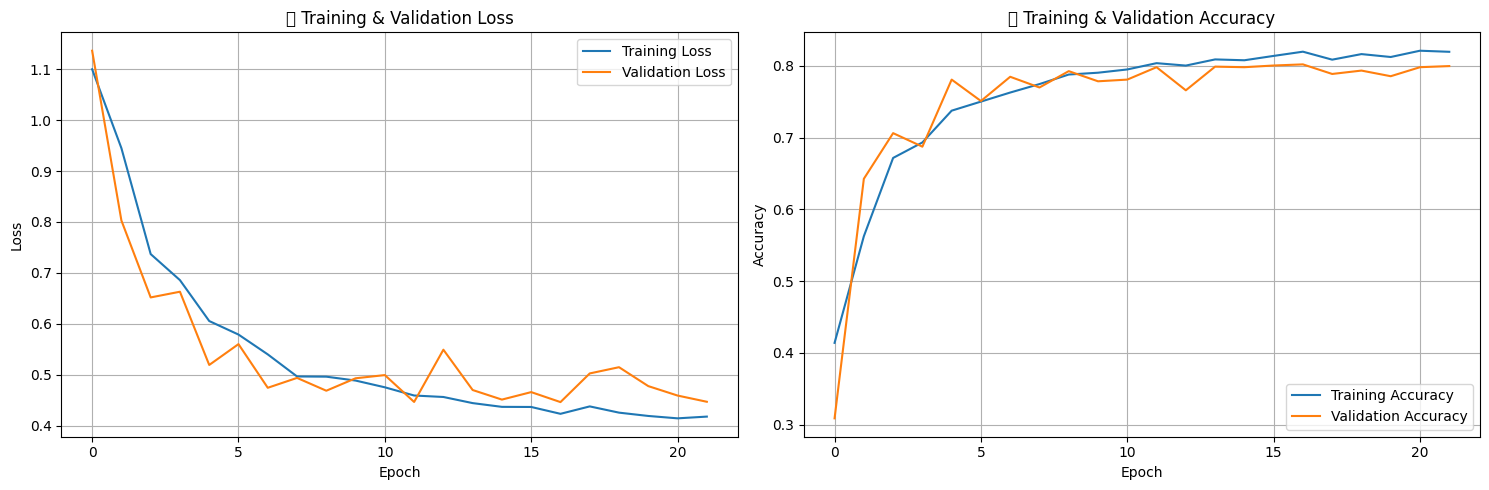


🔍 Memuat model terbaik untuk evaluasi akhir...


Mengevaluasi pada data tes:   0%|          | 0/40 [00:00<?, ?it/s]


      HASIL EVALUASI PADA DATA TES
➡️ Rata-rata Loss : 0.3658
➡️ Akurasi        : 0.8421 (84.21%)

📊 Laporan Klasifikasi (Tabel):
                  precision    recall  f1-score   support

          Netral       0.95      0.97      0.96       575
     Hate Speech       0.74      0.64      0.68       317
Abusive Language       0.75      0.81      0.78       381

        accuracy                           0.84      1273
       macro avg       0.81      0.81      0.81      1273
    weighted avg       0.84      0.84      0.84      1273



/tmp/ipykernel_38/608289723.py:368: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


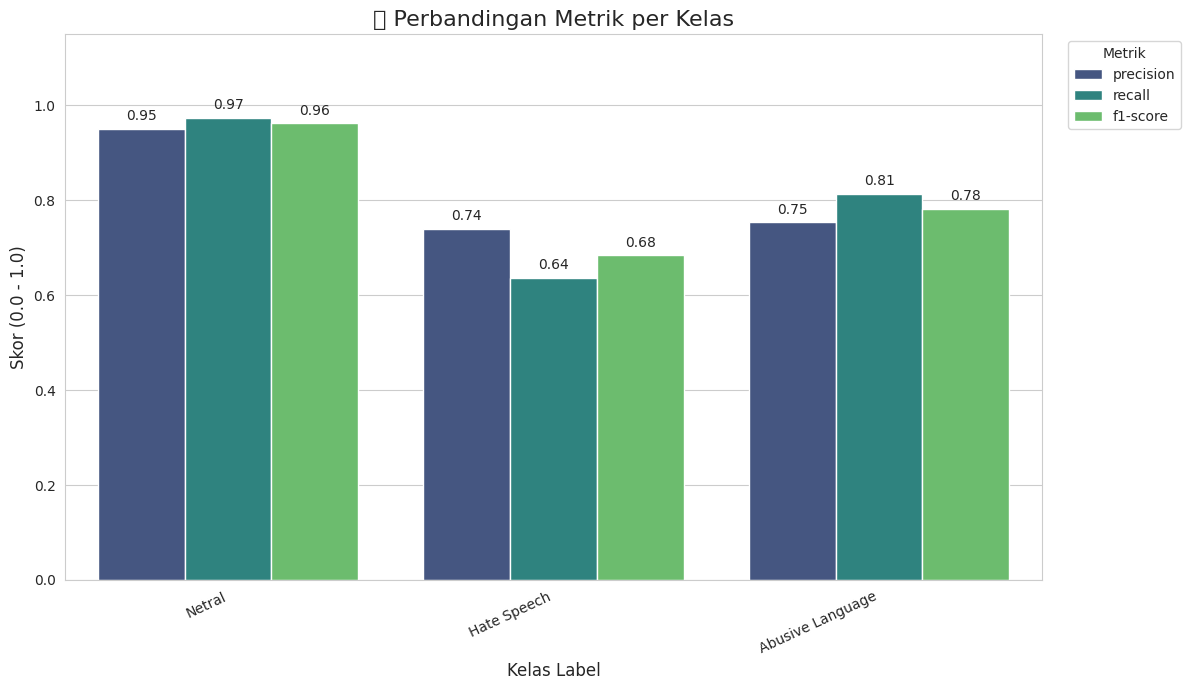


📊 Confusion Matrix:


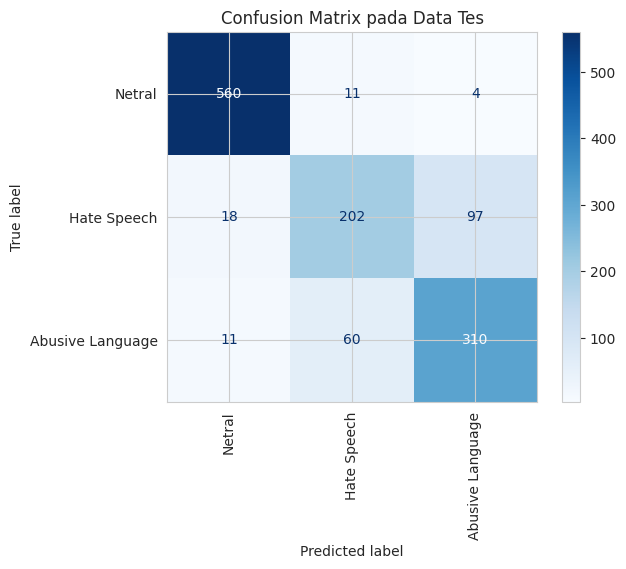

In [6]:
try:
    # --- 1. Muat Vektor FastText (CARA EFISIEN) ---
    file_list = [PATH_ID_VEC, PATH_EN_VEC]
    word_to_index, weights_matrix = load_vectors_and_build_vocab(file_list)
    
    # Konversi matriks ke tensor PyTorch
    weights_matrix_tensor = torch.FloatTensor(weights_matrix)
    VOCAB_SIZE = len(word_to_index)
    
    # --- 2. Proses Data (CSV) ---
    folder_path = '/kaggle/input/tes6conferences'
    train_filename = 'train_data.csv'
    valid_filename = 'validation_data.csv'
    test_filename = 'test_data.csv'
    
    train_path = os.path.join(folder_path, train_filename)
    valid_path = os.path.join(folder_path, valid_filename)
    test_path = os.path.join(folder_path, test_filename)
    
    label_mapping = {'Netral': 0, 'Hate Speech': 1, 'Abusive Language': 2}

    print("Memproses data training...")
    df_train = pd.read_csv(train_path, header=None)
    df_train[['Tweet', 'Label']] = df_train[0].str.rsplit(';', n=1, expand=True)
    df_train = df_train.drop(columns=[0])
    df_train.dropna(subset=['Label', 'Tweet'], inplace=True)
    
    print("\nMemproses data validasi...")
    df_valid = pd.read_csv(valid_path, header=None)
    df_valid[['Tweet', 'Label']] = df_valid[0].str.rsplit(';', n=1, expand=True)
    df_valid = df_valid.drop(columns=[0])
    df_valid.dropna(subset=['Label', 'Tweet'], inplace=True)

    print("\nMemproses data testing...")
    df_test = pd.read_csv(test_path, header=None)
    df_test[['Tweet', 'Label']] = df_test[0].str.rsplit(';', n=1, expand=True)
    df_test = df_test.drop(columns=[0])
    df_test.dropna(subset=['Label', 'Tweet'], inplace=True)

    print(f"\nJumlah data training: {len(df_train)}")
    print(f"Jumlah data validasi: {len(df_valid)}")
    print(f"Jumlah data testing: {len(df_test)}")
    
    # --- 3. Buat Dataset dan DataLoader (MENGGUNAKAN KELAS BARU) ---
    MAX_SEQ_LENGTH = 50 
    
    train_dataset = TextDataset(df_train, word_to_index, label_mapping, max_len=MAX_SEQ_LENGTH)
    valid_dataset = TextDataset(df_valid, word_to_index, label_mapping, max_len=MAX_SEQ_LENGTH)
    test_dataset = TextDataset(df_test, word_to_index, label_mapping, max_len=MAX_SEQ_LENGTH)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
    print("\n✅ Dataset dan DataLoader (Teks-ke-Index) siap.")
    
    # --- 4. Inisialisasi Model, Loss, dan Optimizer ---
    # !!! PENTING: D_MODEL SEKARANG HARUS 300 !!!
    D_MODEL = 300 
    NUM_LAYERS = 6
    NUM_HEADS = 5 
    D_FF = 2048 
    DROPOUT = 0.1
    LEARNING_RATE = 1e-4
    NUM_EPOCHS = 50
    PATIENCE = 5         # <--- TAMBAHAN 1: Definisikan batas kesabaran (misal 5 epoch)
    WEIGHT_DECAY = 0.01
    SAVE_PATH = "/kaggle/working/baselinetransformer1_fasttext.pt"

    NUM_CLASSES = len(label_mapping) 
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Panggil model StableTransformerClassifier YANG SUDAH DIMODIFIKASI
    model = TransformerClassifier(
        # Parameter baru dari FastText:
        vocab_size=VOCAB_SIZE,
        embedding_dim=D_MODEL, # Pastikan ini D_MODEL (300), bukan variabel kosong
        weights_matrix=weights_matrix_tensor,
        
        # Parameter lama Anda:
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        max_seq_length=MAX_SEQ_LENGTH,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    print(f"🚀 Memulai Eksperimen: d_model={D_MODEL}, Optimizer=AdamW, LR={LEARNING_RATE}")
    
    # --- 5. Jalankan Training (DENGAN PATIENCE) ---
    # <--- TAMBAHAN 2: Tambahkan argumen patience=PATIENCE di bawah ini
    train_model(model, train_loader, valid_loader, criterion, optimizer, device, NUM_EPOCHS, SAVE_PATH, patience=PATIENCE)

    # --- 6. Jalankan Evaluasi Akhir ---
    print("\n🔍 Memuat model terbaik untuk evaluasi akhir...")
    model.load_state_dict(torch.load(SAVE_PATH))
    
    idx2label = {v: k for k, v in label_mapping.items()}
    label_names = [idx2label[i] for i in sorted(idx2label.keys())]
    
    eval_model(model, test_loader, criterion, device, label_names)

except Exception as e:
    print(f"❌ TERJADI ERROR: {e}")

**MODIFIKASI (USULAN)**

In [1]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 31.9 MB/s eta 0:00:0000:0100:01m
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is incompat

In [2]:
import re
import string
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from gensim.models import KeyedVectors
import numpy as np
import os

In [3]:
import numpy as np
import os

# --- 1. Konfigurasi ---
# Ganti ini dengan path file .vec Anda yang sebenarnya
PATH_ID_VEC = "/kaggle/input/embeddingfasttezt/cc.id.300.vec"
PATH_EN_VEC = "/kaggle/input/embeddingfasttezt/cc.en.300.vec"
EMBEDDING_DIM = 300 # Pastikan ini 300

def load_vectors_and_build_vocab(file_paths):
    """
    Membaca file .vec, membuat vocab (word_to_index), 
    dan matriks embedding (weights_matrix) secara efisien.
    """
    print("Memulai memuat vektor FastText (cara efisien)...")
    
    # 0. Mulai dengan token spesial <PAD> (padding) dan <UNK> (unknown)
    # <PAD> di index 0, <UNK> di index 1
    word_to_index = {"<PAD>": 0, "<UNK>": 1}
    vectors = []
    
    # Buat vektor untuk PAD (semua nol) dan UNK (vektor acak)
    pad_vector = np.zeros(EMBEDDING_DIM)
    unk_vector = np.random.rand(EMBEDDING_DIM)
    
    vectors.append(pad_vector)
    vectors.append(unk_vector)
    
    # 1. Muat vektor dari semua file
    for filepath in file_paths:
        if not os.path.exists(filepath):
            print(f"PERINGATAN: File {filepath} tidak ditemukan. Melewati.")
            continue
            
        print(f"Memproses {filepath}...")
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                # Lewati header (baris pertama)
                next(f)
                
                # Baca sisa file baris per baris
                for line in f:
                    parts = line.split(' ')
                    word = parts[0]
                    
                    # Hanya tambahkan jika kata belum ada di kamus kita
                    if word not in word_to_index:
                        try:
                            # Ambil vektor angkanya
                            vector_values = [float(val) for val in parts[1:] if val.strip()]
                            
                            # Pastikan dimensinya benar (300)
                            if len(vector_values) == EMBEDDING_DIM:
                                vectors.append(np.array(vector_values))
                                word_to_index[word] = len(word_to_index) # Tambahkan ke kamus
                        except ValueError:
                            # Lewati baris yang korup/aneh
                            pass 
                            
        except Exception as e:
            print(f"Error saat membaca file {filepath}: {e}")
                        
    # 2. Gabungkan semua vektor menjadi satu matriks numpy besar
    weights_matrix = np.stack(vectors, axis=0)
    
    print(f"Selesai. Total {len(word_to_index)} kata unik dimuat.")
    return word_to_index, weights_matrix

# --- 2. Panggil Fungsi ---
# Gabungkan kedua file .vec Anda ke dalam list
file_list = [PATH_ID_VEC, PATH_EN_VEC]

# Panggil fungsi efisien kita
word_to_index, weights_matrix = load_vectors_and_build_vocab(file_list)

VOCAB_SIZE = len(word_to_index)

# --- 3. Tampilkan Hasil (Opsional) ---
print(f"\nUkuran Vokabulari Total (termasuk <PAD> & <UNK>): {VOCAB_SIZE}")
print(f"Bentuk Matriks Bobot (Shape): {weights_matrix.shape}")
print(f"(Bentuk harusnya: ({VOCAB_SIZE}, {EMBEDDING_DIM}))")

# Cek beberapa kata
print(f"\nIndex untuk 'polisi': {word_to_index.get('polisi', 'TIDAK ADA')}")
print(f"Index untuk 'police': {word_to_index.get('police', 'TIDAK ADA')}")
print(f"Index untuk '<UNK>': {word_to_index.get('<UNK>')}")

Memulai memuat vektor FastText (cara efisien)...
Memproses /kaggle/input/embeddingfasttezt/cc.id.300.vec...
Memproses /kaggle/input/embeddingfasttezt/cc.en.300.vec...
Selesai. Total 3418120 kata unik dimuat.

Ukuran Vokabulari Total (termasuk <PAD> & <UNK>): 3418120
Bentuk Matriks Bobot (Shape): (3418120, 300)
(Bentuk harusnya: (3418120, 300))

Index untuk 'polisi': 1731
Index untuk 'police': 39092
Index untuk '<UNK>': 1


In [4]:
class TextDataset(Dataset):
    def __init__(self, dataframe, word_to_index, label_map, max_len=50):
        self.dataframe = dataframe
        self.word_to_index = word_to_index
        self.label_map = label_map
        self.max_len = max_len
        self.tweets = self.dataframe['Tweet'].values
        self.labels = self.dataframe['Label'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        tweet = str(self.tweets[idx])
        label_str = self.labels[idx]
        
        tokens = tweet.lower().split()
        
        # --- INI PROSES UTAMANYA ---
        # Mengubah kata (string) menjadi angka (index)
        token_indices = []
        for token in tokens:
            # Gunakan .get(token, 1) untuk mendapatkan index <UNK> (yaitu 1)
            # jika kata tidak ada di kamus
            index = self.word_to_index.get(token, 1) 
            token_indices.append(index)
            
        # Padding (menambahkan angka 0) atau Truncating (memotong)
        if len(token_indices) < self.max_len:
            pad_width = self.max_len - len(token_indices)
            token_indices.extend([0] * pad_width) # 0 adalah index <PAD>
        else:
            token_indices = token_indices[:self.max_len]
            
        # Konversi label string ke angka
        label_int = self.label_map.get(label_str, 0) # Default ke 0 (Netral) jika ada error

        # Ubah ke tensor
        indices_tensor = torch.tensor(token_indices, dtype=torch.long)
        label_tensor = torch.tensor(label_int, dtype=torch.long)
        
        return indices_tensor, label_tensor

In [5]:
# Modifikasi Encoder Transformer (MENGGUNAKAN 1 LAYER NORMALIZATION, 1 LAYER AGRC, 1 LAYER FEEDFORWARD)
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import seaborn as sns
import time

# --- TIDAK BERUBAH: Multi-Head Attention, Positional Encoding, AGRC, FFN ---
# Semua kelas pembantu ini tetap sama.

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.w_q(Q))
        K = self.split_heads(self.w_k(K))
        V = self.split_heads(self.w_v(V))
        attention_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.w_o(self.combine_heads(attention_output))
        return output

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class AdaptiveGatedResidualConnection(nn.Module):
    def __init__(self, d_model):
        super(AdaptiveGatedResidualConnection, self).__init__()
        self.d_model = d_model
        self.gate_linear = nn.Linear(d_model * 2, d_model)

    def forward(self, x_residual, x_sublayer):
        concatenated = torch.cat([x_residual, x_sublayer], dim=-1)
        gate = torch.sigmoid(self.gate_linear(concatenated))
        return gate * x_sublayer + (1 - gate) * x_residual

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU() 

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))


# --- MODIFIKASI UTAMA: Encoder Layer (POST-NORM) ---
# Ini adalah arsitektur yang STABIL (gaya "Attention Is All You Need")
# Urutan: (MHA -> AGRC -> LN) -> (FFN -> Add -> LN)
#
class StableEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(StableEncoderLayer, self).__init__()
        
        # --- Sub-lapisan 1: Attention ---
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.agrc_attn = AdaptiveGatedResidualConnection(d_model) # (AGRC Anda)
        self.norm1 = nn.LayerNorm(d_model) # (LN ke-1, SETELAH AGRC)
        self.dropout_attn = nn.Dropout(dropout)

        # --- Sub-lapisan 2: Feed Forward ---
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm2 = nn.LayerNorm(d_model) # (LN ke-2, SETELAH FFN)
        self.dropout_ffn = nn.Dropout(dropout)


    def forward(self, x, mask):
        # --- Proses Sub-lapisan 1 (Attention) ---
        # 1. Lewatkan ke MHA (input adalah x)
        attn_output = self.self_attn(x, x, x, mask)
        # 2. Terapkan AGRC
        x_agrc = self.agrc_attn(x_residual=x, x_sublayer=self.dropout_attn(attn_output))
        # 3. Normalisasi SETELAHNYA
        x_norm1 = self.norm1(x_agrc)

        # --- Proses Sub-lapisan 2 (Feed Forward) ---
        # 1. Lewatkan ke FFN (input adalah x_norm1)
        ffn_output = self.ffn(x_norm1)
        # 2. Terapkan Residual 'Add' standar
        x_add = x_norm1 + self.dropout_ffn(ffn_output)
        # 3. Normalisasi SETELAHNYA
        x_norm2 = self.norm2(x_add)

        return x_norm2 # Output sudah dinormalisasi dan stabil

# --- MODEL UTAMA: Transformer Classifier ---
# --- MODIFIKASI KECIL: Hapus LayerNorm final ---
# --- MODEL UTAMA: Transformer Classifier (VERSI BARU DENGAN EMBEDDING) ---
class StableTransformerClassifier(nn.Module):
    def __init__(self, 
                 # Parameter BARU untuk Embedding:
                 vocab_size, 
                 embedding_dim, 
                 weights_matrix, 
                 
                 # Parameter LAMA Anda:
                 d_model, 
                 num_layers, 
                 num_heads, 
                 d_ff, 
                 max_seq_length, 
                 dropout, 
                 num_classes):
        
        super(StableTransformerClassifier, self).__init__()
        
        # --- PERUBAHAN 1: TAMBAHKAN EMBEDDING LAYER ---
        # 1. Buat Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # 2. Muat bobot FastText (pastikan weights_matrix adalah torch.FloatTensor)
        self.embedding.load_state_dict({'weight': weights_matrix})
        
        # 3. Bekukan bobot (SANGAT PENTING!)
        self.embedding.weight.requires_grad = False
        
        # 4. Validasi: d_model Anda HARUS sama dengan embedding_dim (yaitu 300)
        assert d_model == embedding_dim, f"Kesalahan: d_model ({d_model}) harus sama dengan embedding_dim ({embedding_dim})!"

        # --- Sisa __init__ Anda (TIDAK BERUBAH) ---
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)
        self.layers = nn.ModuleList(
            [StableEncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.dropout = nn.Dropout(dropout)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, mask=None): 
        # --- PERUBAHAN 2: UBAH INPUT 'x' ---
        # 'x' sekarang adalah (B, L) berisi ANGKA INDEX, bukan vektor
        
        # 1. Lewatkan index ke embedding layer
        # Output: (B, L, D_MODEL)
        x_embedded = self.embedding(x) 
        
        # 2. Gunakan x_embedded di sisa model Anda
        src_with_pos = self.positional_encoding(x_embedded) # <-- Gunakan x_embedded
        enc_output = self.dropout(src_with_pos)

        # --- Sisa forward-pass Anda (TIDAK BERUBAH) ---
        for layer in self.layers:
            enc_output = layer(enc_output, mask)

        # (Komentar Anda sebelumnya DIHAPUS, ini TIDAK BERUBAH)
        pooled_output = self.avg_pool(enc_output.transpose(1, 2)).squeeze(-1)
        logits = self.classifier(pooled_output)

        return logits
        
# --- Sisa kode (train_model, eval_model, dll) TIDAK BERUBAH ---
# Anda bisa langsung copy-paste sisa kode Anda di sini.
def plot_metrics(history):
    """Fungsi untuk menampilkan grafik loss dan accuracy."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot untuk Loss
    ax1.plot(history['train_loss'], label='Training Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title('📈 Training & Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot untuk Accuracy
    ax2.plot(history['train_acc'], label='Training Accuracy')
    ax2.plot(history['val_acc'], label='Validation Accuracy')
    ax2.set_title('🎯 Training & Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, save_path, patience=5):
    """
    Fungsi untuk melatih model dengan progress bar, validasi per epoch,
    Early Stopping, Timer, dan menampilkan grafik loss/accuracy di akhir.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    
    # --- VARIABEL TAMBAHAN ---
    patience_counter = 0      # Menghitung berapa kali loss tidak turun
    start_time = time.time()  # Waktu mulai training
    
    model.to(device)

    print(f"🚀 Memulai proses training (Max Epochs: {epochs}, Patience: {patience})...")
    
    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time() # Catat waktu awal epoch
        
        # --- Tahap Training ---
        model.train()
        total_loss, total_correct = 0, 0
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Training]", leave=False)

        for X, y in train_bar:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(output, dim=1)
            total_correct += (preds == y).sum().item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = total_correct / len(train_loader.dataset)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)

        # --- Tahap Validasi ---
        model.eval()
        total_val_loss, total_val_correct = 0, 0
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Validation]", leave=False)
            for X, y in val_bar:
                X, y = X.to(device), y.to(device)
                output = model(X)
                loss = criterion(output, y)
                
                total_val_loss += loss.item()
                preds = torch.argmax(output, dim=1)
                total_val_correct += (preds == y).sum().item()
                val_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = total_val_correct / len(val_loader.dataset)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_accuracy)

        # --- HITUNG DURASI EPOCH ---
        epoch_end_time = time.time()
        epoch_mins, epoch_secs = divmod(epoch_end_time - epoch_start_time, 60)

        # Print hasil epoch + durasi
        print(f"Epoch {epoch}/{epochs} | Time: {int(epoch_mins)}m {int(epoch_secs)}s")
        print(f"   Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}") 
        print(f"   Val Loss:   {avg_val_loss:.4f}, Val Acc:   {val_accuracy:.4f}")

        # --- LOGIKA CHECKPOINT & EARLY STOPPING ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            print(f"   ✅ Model disimpan di {save_path} (Val Loss membaik)")
            patience_counter = 0 # Reset counter jika performa membaik
        else:
            patience_counter += 1
            print(f"   ⚠️ Loss tidak membaik. Patience: {patience_counter}/{patience}")
            
            # Cek apakah harus berhenti paksa
            if patience_counter >= patience:
                print(f"\n🛑 EARLY STOPPING DIPICU!")
                print(f"   Training berhenti karena validasi loss tidak turun selama {patience} epoch.")
                break # Keluar dari loop

    # --- INFORMASI AKHIR ---
    total_end_time = time.time()
    total_duration = total_end_time - start_time
    total_mins, total_secs = divmod(total_duration, 60)
    
    print("\n" + "="*40)
    print("🎉 Training selesai!")
    print(f"⏱️  Total Durasi: {int(total_mins)} menit {int(total_secs)} detik")
    print(f"📉 Best Val Loss: {best_val_loss:.4f}")
    print("="*40)
    
    # --- Menampilkan Grafik ---
    print("📊 Menampilkan grafik performa model...")
    plot_metrics(history)
    
    return history
    
def plot_classification_report(report_dict, label_names):
    """
    Fungsi untuk membuat diagram batang dari classification report.
    (Membutuhkan import seaborn as sns di atas)
    """
    # Mengubah dictionary laporan menjadi DataFrame pandas
    # Mengambil data per kelas saja, bukan rata-rata/keseluruhan
    report_df = pd.DataFrame(report_dict).T
    # Filter agar hanya label_names yang valid yang diambil
    valid_labels = [label for label in label_names if label in report_df.index]
    report_df = report_df.loc[valid_labels]

    # Mengatur ulang DataFrame agar mudah diplot
    report_df = report_df[['precision', 'recall', 'f1-score']].reset_index()
    report_df = report_df.rename(columns={'index': 'Label'})
    
    # "Melt" DataFrame agar bisa dibuat grouped bar plot
    melted_df = report_df.melt(id_vars='Label', var_name='Metric', value_name='Score')

    # Membuat plot
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    bar_plot = sns.barplot(data=melted_df, x='Label', y='Score', hue='Metric', palette='viridis')

    # Menambahkan label angka di atas setiap batang
    for p in bar_plot.patches:
        bar_plot.annotate(format(p.get_height(), '.2f'),
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha = 'center', va = 'center',
                           xytext = (0, 9),
                           textcoords = 'offset points')

    plt.title('📊 Perbandingan Metrik per Kelas', fontsize=16)
    plt.xlabel('Kelas Label', fontsize=12)
    plt.ylabel('Skor (0.0 - 1.0)', fontsize=12)
    plt.ylim(0, 1.15) # Beri sedikit ruang di atas untuk label angka
    plt.xticks(rotation=25, ha='right') # Rotasi label x agar tidak tumpang tindih
    plt.legend(title='Metrik', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def eval_model(model, data_loader, criterion, device, label_names):
    """
    Fungsi untuk mengevaluasi model, menampilkan laporan teks, 
    diagram batang metrik, dan confusion matrix.
    """
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    eval_bar = tqdm(data_loader, desc="Mengevaluasi pada data tes")
    with torch.no_grad():
        for X, y in eval_bar:
            X, y = X.to(device), y.to(device)
            output = model(X) # Mask tidak dipakai di sini, oke
            loss = criterion(output, y)
            total_loss += loss.item()
            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Hitung metrik keseluruhan
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)

    # Tampilkan ringkasan hasil
    print("\n" + "="*40)
    print("       HASIL EVALUASI PADA DATA TES")
    print("="*40)
    print(f"➡️ Rata-rata Loss : {avg_loss:.4f}")
    print(f"➡️ Akurasi        : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("="*40, "\n")
    
    # 1. Hasilkan laporan dalam bentuk teks dan dictionary
    report_text = classification_report(all_labels, all_preds, target_names=label_names, zero_division=0)
    report_dict = classification_report(all_labels, all_preds, target_names=label_names, zero_division=0, output_dict=True)
    
    # 2. Tampilkan laporan klasifikasi dalam bentuk teks
    print("📊 Laporan Klasifikasi (Tabel):")
    print(report_text)
    
    # 3. Panggil fungsi baru untuk menampilkan diagram batang
    plot_classification_report(report_dict, label_names)
    
    # Tampilkan confusion matrix
    print("\n📊 Confusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title('Confusion Matrix pada Data Tes')
    plt.show()

⏳ Memuat vektor FastText (ini mungkin memakan waktu)...
Memulai memuat vektor FastText (cara efisien)...
Memproses /kaggle/input/embeddingfasttezt/cc.en.300.vec...
Memproses /kaggle/input/embeddingfasttezt/cc.en.300.vec...
Selesai. Total 2000002 kata unik dimuat.
✅ Selesai. Total 2000002 kata unik dimuat.

Memproses data training...
Memproses data validasi...
Memproses data testing...

Jumlah data training: 5936
Jumlah data validasi: 1273
Jumlah data testing: 1273

✅ Dataset dan DataLoader (Teks-ke-Index) siap.
🚀 Memulai Eksperimen: d_model=300, Optimizer=AdamW, LR=0.0001
🚀 Memulai proses training (Max Epochs: 50, Patience: 5)...


Epoch 1/50 [Training]:   0%|          | 0/186 [00:00<?, ?it/s]

Epoch 1/50 [Validation]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/50 | Time: 0m 9s
   Train Loss: 0.9997, Train Acc: 0.5303
   Val Loss:   0.9229, Val Acc:   0.5625
   ✅ Model disimpan di /kaggle/working/stable_transformer_fasttext.pt (Val Loss membaik)


Epoch 2/50 [Training]:   0%|          | 0/186 [00:00<?, ?it/s]

...

Epoch 17/50 | Time: 0m 10s
   Train Loss: 0.2666, Train Acc: 0.8907
   Val Loss:   0.3683, Val Acc:   0.8445
   ⚠️ Loss tidak membaik. Patience: 4/5


Epoch 18/50 [Training]:   0%|          | 0/186 [00:00<?, ?it/s]

Epoch 18/50 [Validation]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 18/50 | Time: 0m 10s
   Train Loss: 0.2587, Train Acc: 0.8878
   Val Loss:   0.3844, Val Acc:   0.8405
   ⚠️ Loss tidak membaik. Patience: 5/5

🛑 EARLY STOPPING DIPICU!
   Training berhenti karena validasi loss tidak turun selama 5 epoch.

🎉 Training selesai!
⏱️  Total Durasi: 3 menit 43 detik
📉 Best Val Loss: 0.3618
📊 Menampilkan grafik performa model...


/tmp/ipykernel_38/1790303061.py:217: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_38/1790303061.py:217: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


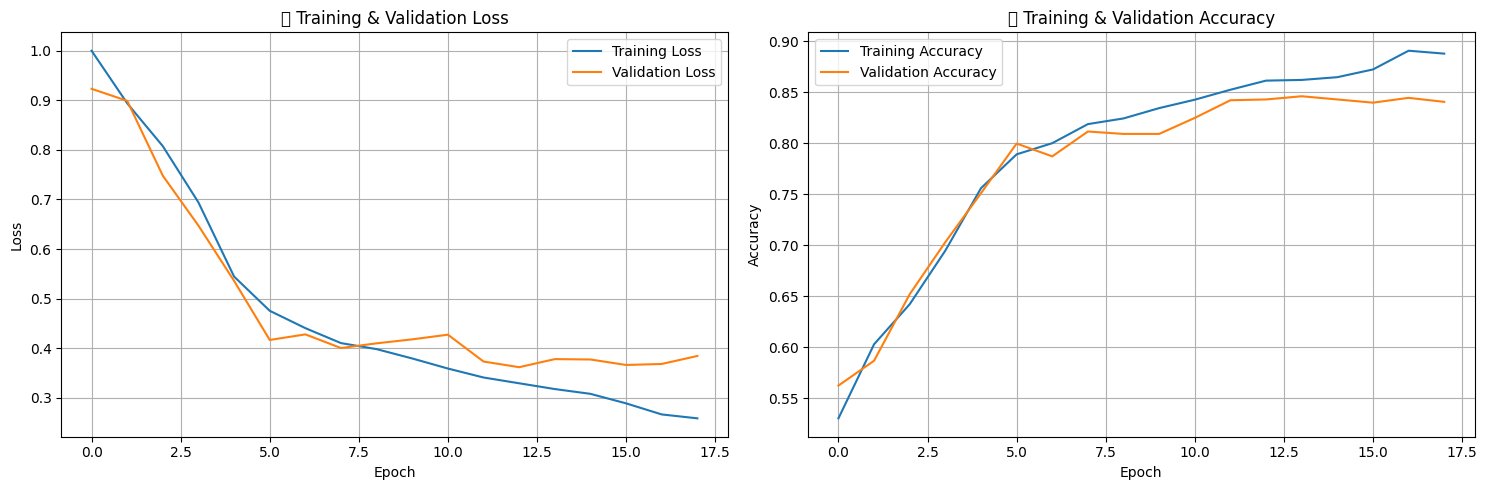


🔍 Memuat model terbaik untuk evaluasi akhir...


Mengevaluasi pada data tes:   0%|          | 0/40 [00:00<?, ?it/s]


       HASIL EVALUASI PADA DATA TES
➡️ Rata-rata Loss : 0.3495
➡️ Akurasi        : 0.8500 (85.00%)

📊 Laporan Klasifikasi (Tabel):
                  precision    recall  f1-score   support

          Netral       0.96      0.97      0.96       575
     Hate Speech       0.76      0.63      0.69       317
Abusive Language       0.76      0.85      0.80       381

        accuracy                           0.85      1273
       macro avg       0.83      0.82      0.82      1273
    weighted avg       0.85      0.85      0.85      1273



/tmp/ipykernel_38/1790303061.py:362: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


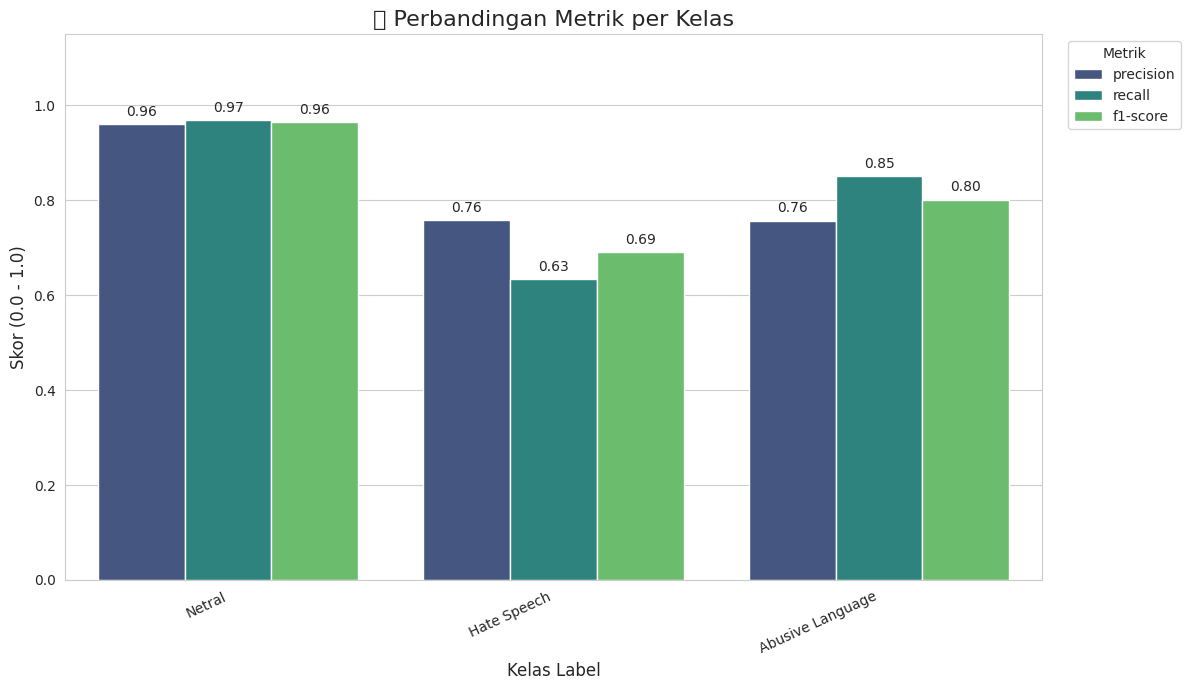


📊 Confusion Matrix:


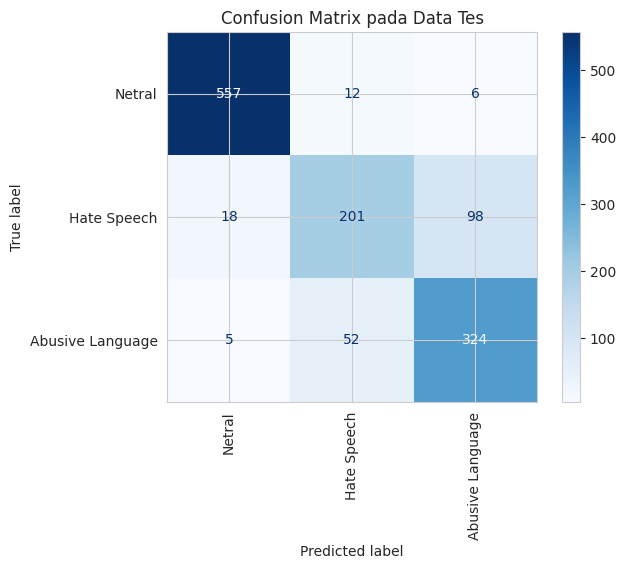

In [6]:
try:
    # --- 1. DEFINISI PATH FASTTEXT (WAJIB DISESUAIKAN) ---
    # Cek path ini di menu Input (sebelah kanan Kaggle). 
    # Klik "Copy File Path" pada file .vec yang kamu punya.
    PATH_ID_VEC = '/kaggle/input/embeddingfasttezt/cc.en.300.vec'  # <--- GANTI SESUAI PATH KAMU
    PATH_EN_VEC = '/kaggle/input/embeddingfasttezt/cc.en.300.vec'     # <--- GANTI SESUAI PATH KAMU

    print("⏳ Memuat vektor FastText (ini mungkin memakan waktu)...")
    file_list = [PATH_ID_VEC, PATH_EN_VEC]
    
    # Asumsi fungsi load_vectors_and_build_vocab sudah ada di cell sebelumnya
    word_to_index, weights_matrix = load_vectors_and_build_vocab(file_list)
    
    # --- SAFETY CHECK: Pastikan vektor benar-benar termuat ---
    print(f"✅ Selesai. Total {len(word_to_index)} kata unik dimuat.")
    if len(word_to_index) < 100:
        raise ValueError("❌ GAGAL MEMUAT VEKTOR! Jumlah kata terlalu sedikit. Periksa path file .vec Anda!")

    # Konversi matriks ke tensor PyTorch
    weights_matrix_tensor = torch.FloatTensor(weights_matrix)
    VOCAB_SIZE = len(word_to_index)
    
    # --- 2. Proses Data (CSV) ---
    folder_path = '/kaggle/input/tes6conferences'
    train_filename = 'train_data.csv'
    valid_filename = 'validation_data.csv'
    test_filename = 'test_data.csv'
    
    train_path = os.path.join(folder_path, train_filename)
    valid_path = os.path.join(folder_path, valid_filename)
    test_path = os.path.join(folder_path, test_filename)
    
    label_mapping = {'Netral': 0, 'Hate Speech': 1, 'Abusive Language': 2}

    print("\nMemproses data training...")
    df_train = pd.read_csv(train_path, header=None)
    df_train[['Tweet', 'Label']] = df_train[0].str.rsplit(';', n=1, expand=True)
    df_train = df_train.drop(columns=[0])
    df_train.dropna(subset=['Label', 'Tweet'], inplace=True)
    
    print("Memproses data validasi...")
    df_valid = pd.read_csv(valid_path, header=None)
    df_valid[['Tweet', 'Label']] = df_valid[0].str.rsplit(';', n=1, expand=True)
    df_valid = df_valid.drop(columns=[0])
    df_valid.dropna(subset=['Label', 'Tweet'], inplace=True)

    print("Memproses data testing...")
    df_test = pd.read_csv(test_path, header=None)
    df_test[['Tweet', 'Label']] = df_test[0].str.rsplit(';', n=1, expand=True)
    df_test = df_test.drop(columns=[0])
    df_test.dropna(subset=['Label', 'Tweet'], inplace=True)

    print(f"\nJumlah data training: {len(df_train)}")
    print(f"Jumlah data validasi: {len(df_valid)}")
    print(f"Jumlah data testing: {len(df_test)}")
    
    # --- 3. Buat Dataset dan DataLoader ---
    MAX_SEQ_LENGTH = 50 
    
    train_dataset = TextDataset(df_train, word_to_index, label_mapping, max_len=MAX_SEQ_LENGTH)
    valid_dataset = TextDataset(df_valid, word_to_index, label_mapping, max_len=MAX_SEQ_LENGTH)
    test_dataset = TextDataset(df_test, word_to_index, label_mapping, max_len=MAX_SEQ_LENGTH)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
    print("\n✅ Dataset dan DataLoader (Teks-ke-Index) siap.")
    
    # --- 4. Inisialisasi Model, Loss, dan Optimizer ---
    # !!! PENTING: D_MODEL HARUS 300 (Sesuai FastText) !!!
    D_MODEL = 300 
    NUM_LAYERS = 6
    NUM_HEADS = 4 
    D_FF = 2048 
    DROPOUT = 0.1
    LEARNING_RATE = 1e-4
    NUM_EPOCHS = 50
    PATIENCE = 5         # Batas kesabaran Early Stopping
    WEIGHT_DECAY = 0.01
    SAVE_PATH = "/kaggle/working/stable_transformer_fasttext.pt" # Saya ubah nama file agar sesuai

    NUM_CLASSES = len(label_mapping) 
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- PENTING: Menggunakan StableTransformerClassifier ---
    model = StableTransformerClassifier(
        # Parameter untuk Embedding:
        vocab_size=VOCAB_SIZE,
        embedding_dim=D_MODEL, 
        weights_matrix=weights_matrix_tensor,
        
        # Parameter Arsitektur:
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        max_seq_length=MAX_SEQ_LENGTH,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    print(f"🚀 Memulai Eksperimen: d_model={D_MODEL}, Optimizer=AdamW, LR={LEARNING_RATE}")
    
    # --- 5. Jalankan Training (Dengan Patience & Timer) ---
    train_model(model, train_loader, valid_loader, criterion, optimizer, device, NUM_EPOCHS, SAVE_PATH, patience=PATIENCE)

    # --- 6. Jalankan Evaluasi Akhir ---
    print("\n🔍 Memuat model terbaik untuk evaluasi akhir...")
    model.load_state_dict(torch.load(SAVE_PATH))
    
    idx2label = {v: k for k, v in label_mapping.items()}
    label_names = [idx2label[i] for i in sorted(idx2label.keys())]
    
    eval_model(model, test_loader, criterion, device, label_names)

except ValueError as ve:
    print(f"❌ ERROR DATA/VEKTOR: {ve}")
except Exception as e:
    print(f"❌ TERJADI ERROR LAIN: {e}")
    import traceback
    traceback.print_exc()